In [ ]:
# ═══════════════════════════════════════════════════
# CELL 1 — Setup (Improved Temporal)
# ═══════════════════════════════════════════════════
import sys
import os
import warnings

sys.path.append('..')
os.chdir("..")
print("CWD:", os.getcwd())

import mlflow
print("Tracking URI:", mlflow.get_tracking_uri())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

print("✅ Setup complete (Improved Temporal)")

✅ Setup complete


In [2]:
# ═══════════════════════════════════════════════════
# CELL 2 — Load Temporal Data with Better Feature Engineering
# ═══════════════════════════════════════════════════
raw_path = Path("../data/raw/")

train_keywords = ['Monday', 'Tuesday', 'Wednesday']
test_keywords = ['Thursday', 'Friday']

csv_files = list(raw_path.glob("*.csv"))

# Load train days
train_dfs = []
for f in csv_files:
    if any(day in f.name for day in train_keywords):
        print(f"  [TRAIN] {f.name}")
        temp = pd.read_csv(f, low_memory=False)
        temp.columns = temp.columns.str.strip().str.replace(' ', '_').str.replace('/', '_').str.lower()
        train_dfs.append(temp)

# Load test days
test_dfs = []
for f in csv_files:
    if any(day in f.name for day in test_keywords):
        print(f"  [TEST]  {f.name}")
        temp = pd.read_csv(f, low_memory=False)
        temp.columns = temp.columns.str.strip().str.replace(' ', '_').str.replace('/', '_').str.lower()
        test_dfs.append(temp)

df_train = pd.concat(train_dfs, ignore_index=True)
df_test = pd.concat(test_dfs, ignore_index=True)

# Binary labels
df_train['label_binary'] = (df_train['label'] != 'BENIGN').astype(int)
df_test['label_binary'] = (df_test['label'] != 'BENIGN').astype(int)

print(f"\n  Train: {len(df_train):,} ({df_train['label_binary'].sum():,} attacks)")
print(f"  Test:  {len(df_test):,} ({df_test['label_binary'].sum():,} attacks)")

# Show attack types in each set
print(f"\n  Train attack types:")
for label, count in df_train['label'].value_counts().items():
    if label != 'BENIGN':
        print(f"    → {label}: {count:,}")

print(f"\n  Test attack types:")
for label, count in df_test['label'].value_counts().items():
    if label != 'BENIGN':
        print(f"    → {label}: {count:,}")

  [TRAIN] Monday-WorkingHours.pcap_ISCX.csv
  [TRAIN] Tuesday-WorkingHours.pcap_ISCX.csv
  [TRAIN] Wednesday-workingHours.pcap_ISCX.csv
  [TEST]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  [TEST]  Friday-WorkingHours-Morning.pcap_ISCX.csv
  [TEST]  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  [TEST]  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  [TEST]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv

  Train: 1,668,530 (266,507 attacks)
  Test:  1,162,213 (291,139 attacks)

  Train attack types:
    → DoS Hulk: 231,073
    → DoS GoldenEye: 10,293
    → FTP-Patator: 7,938
    → SSH-Patator: 5,897
    → DoS slowloris: 5,796
    → DoS Slowhttptest: 5,499
    → Heartbleed: 11

  Test attack types:
    → PortScan: 158,930
    → DDoS: 128,027
    → Bot: 1,966
    → Web Attack � Brute Force: 1,507
    → Web Attack � XSS: 652
    → Infiltration: 36
    → Web Attack � Sql Injection: 21


In [3]:
# ═══════════════════════════════════════════════════
# CELL 3 — Feature Engineering for Generalization
#
# The key problem: model trained on specific attacks
# doesn't recognize new attack TYPES.
#
# Solution: engineer features that capture GENERAL
# attack behavior, not specific attack signatures.
# ═══════════════════════════════════════════════════

def engineer_generalizable_features(df):
    """
    Create features that describe ANOMALOUS BEHAVIOR
    regardless of specific attack type.
    
    These features should detect:
    - Unusual traffic volume
    - Abnormal packet patterns
    - Suspicious timing
    - Asymmetric communication
    """
    
    # Common numeric columns
    exclude = ['label', 'label_binary']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in exclude]
    
    # Clean inf/nan first
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    
    # ── Traffic Asymmetry Features ──
    # Attacks are often one-directional
    fwd = df['total_fwd_packets'].fillna(0)
    bwd = df['total_backward_packets'].fillna(0)
    total = fwd + bwd
    
    df['fwd_ratio'] = np.where(total > 0, fwd / total, 0)
    df['bwd_ratio'] = np.where(total > 0, bwd / total, 0)
    df['fwd_bwd_diff'] = np.abs(fwd - bwd)
    
    df['bidirectional'] = np.where(
        total > 0,
        2 * np.minimum(fwd, bwd) / total,
        0
    )
    
    # ── Packet Size Anomaly Features ──
    if 'fwd_packet_length_mean' in df.columns:
        mean_col = df['fwd_packet_length_mean'].fillna(0)
        std_col = df.get('fwd_packet_length_std', pd.Series(0, index=df.index)).fillna(0)
        
        df['pkt_size_cv'] = np.where(
            mean_col > 0, std_col / mean_col, 0
        )
        df['is_tiny_packets'] = (mean_col < 100).astype(int)
        df['is_large_packets'] = (mean_col > 1000).astype(int)
    
    # ── Timing Anomaly Features ──
    if 'flow_duration' in df.columns:
        duration = df['flow_duration'].fillna(0)
        duration_sec = duration / 1e6
        
        df['is_short_flow'] = (duration < 1000).astype(int)
        df['is_long_flow'] = (duration > 60000000).astype(int)
        
        df['pkt_rate'] = np.where(
            duration_sec > 0, total / duration_sec, 0
        )
        
        if 'total_length_of_fwd_packets' in df.columns:
            total_bytes = (df['total_length_of_fwd_packets'].fillna(0) +
                          df.get('total_length_of_bwd_packets', 
                                pd.Series(0, index=df.index)).fillna(0))
            df['byte_rate'] = np.where(
                duration_sec > 0, total_bytes / duration_sec, 0
            )
    
    # ── IAT Anomaly Features ──
    if 'flow_iat_mean' in df.columns:
        iat_mean = df['flow_iat_mean'].fillna(0)
        iat_std = df.get('flow_iat_std', pd.Series(0, index=df.index)).fillna(0)
        
        df['iat_cv'] = np.where(
            iat_mean > 0, iat_std / iat_mean, 0
        )
        df['is_bursty'] = (df['iat_cv'] > 2).astype(int)
    
    # ── Flag Anomaly Features ──
    flag_cols = [c for c in df.columns if 'flag' in c.lower() and c in numeric_cols]
    if flag_cols:
        df['total_flags'] = df[flag_cols].fillna(0).sum(axis=1)
        
        syn_cols = [c for c in flag_cols if 'syn' in c.lower()]
        ack_cols = [c for c in flag_cols if 'ack' in c.lower()]
        
        if syn_cols and ack_cols:
            syn_val = df[syn_cols[0]].fillna(0)
            ack_val = df[ack_cols[0]].fillna(0)
            df['syn_ack_ratio'] = np.where(
                ack_val > 0, syn_val / ack_val, syn_val
            )
    
    # ── Bulk Transfer Features ──
    if 'subflow_fwd_bytes' in df.columns:
        sfb = df['subflow_fwd_bytes'].fillna(0)
        sbb = df.get('subflow_bwd_bytes', pd.Series(0, index=df.index)).fillna(0)
        df['subflow_ratio'] = np.where(
            (sfb + sbb) > 0, sfb / (sfb + sbb), 0
        )
    
    return df

# Apply to both sets
print("Engineering features for train set...")
df_train = engineer_generalizable_features(df_train)

print("Engineering features for test set...")
df_test = engineer_generalizable_features(df_test)

print("✅ Feature engineering complete")

Engineering features for train set...
Engineering features for test set...
✅ Feature engineering complete


In [4]:
# ═══════════════════════════════════════════════════
# CELL 4 — Prepare and Clean Data
# ═══════════════════════════════════════════════════
exclude = ['label', 'label_binary']
non_numeric_train = df_train.select_dtypes(exclude=[np.number]).columns.tolist()
non_numeric_test = df_test.select_dtypes(exclude=[np.number]).columns.tolist()
all_exclude = list(set(exclude + non_numeric_train + non_numeric_test))

train_numeric = [c for c in df_train.select_dtypes(include=[np.number]).columns 
                 if c not in all_exclude]
test_numeric = [c for c in df_test.select_dtypes(include=[np.number]).columns 
                if c not in all_exclude]

common_cols = sorted(list(set(train_numeric) & set(test_numeric)))

print(f"Common features: {len(common_cols)}")

# Clean
X_train = df_train[common_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
y_train = df_train['label_binary'].values
X_test = df_test[common_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
y_test = df_test['label_binary'].values

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train: {X_train.shape} (attacks: {y_train.sum():,})")
print(f"X_test:  {X_test.shape} (attacks: {y_test.sum():,})")
print("✅ Data ready")

Common features: 94
X_train: (1668530, 94) (attacks: 266,507)
X_test:  (1162213, 94) (attacks: 291,139)
✅ Data ready


In [5]:
# ═══════════════════════════════════════════════════
# CELL 5 — Train with Optimized Hyperparameters
#
# Key changes:
# 1. scale_pos_weight: handles class imbalance
# 2. Lower max_depth: prevents overfitting to
#    specific attack patterns
# 3. Higher regularization: better generalization
# ═══════════════════════════════════════════════════

# Calculate class weight
n_benign = (y_train == 0).sum()
n_attack = (y_train == 1).sum()
scale_weight = n_benign / n_attack

print(f"Class weight: {scale_weight:.2f}")
print(f"(Benign: {n_benign:,} / Attack: {n_attack:,})")

xgb_optimized = XGBClassifier(
    n_estimators=500,
    max_depth=6,              # Lower = less overfitting
    learning_rate=0.05,       # Lower = more careful learning
    subsample=0.7,            # Less data per tree = more diversity
    colsample_bytree=0.7,     # Less features per tree = more diversity
    min_child_weight=5,       # Prevent splits on tiny groups
    gamma=0.1,                # Regularization
    reg_alpha=0.1,            # L1 regularization
    reg_lambda=1.0,           # L2 regularization
    scale_pos_weight=scale_weight,  # Handle class imbalance
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

print("\nTraining optimized XGBoost...")
xgb_optimized.fit(X_train, y_train, verbose=False)
print("✅ Training complete")

Class weight: 5.26
(Benign: 1,402,023 / Attack: 266,507)

Training optimized XGBoost...
✅ Training complete


In [6]:
# ═══════════════════════════════════════════════════
# CELL 6 — Evaluate with Different Thresholds
#
# Default threshold is 0.5 (if P(attack) > 0.5 → attack)
# But we can LOWER the threshold to catch more attacks
# at the cost of more false alarms.
#
# This is a CRITICAL decision in telecom security:
# - Miss an attack = potential breach
# - False alarm = wasted investigation time
# ═══════════════════════════════════════════════════

y_scores = xgb_optimized.predict_proba(X_test)[:, 1]

# Test multiple thresholds
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]

print(f"\n{'Threshold':>10} {'Precision':>10} {'Recall':>10} "
      f"{'F1':>10} {'False Alarms':>15}")
print(f"{'─' * 55}")

best_f1 = 0
best_threshold = 0.5

for t in thresholds:
    y_pred_t = (y_scores >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    
    marker = ""
    if f > best_f1:
        best_f1 = f
        best_threshold = t
        marker = " ← best F1"
    
    print(f"{t:>10.2f} {p:>10.4f} {r:>10.4f} {f:>10.4f} "
          f"{fp:>15,}{marker}")

print(f"\n✅ Best threshold: {best_threshold} (F1={best_f1:.4f})")


 Threshold  Precision     Recall         F1    False Alarms
───────────────────────────────────────────────────────
      0.50     0.9970     0.2503     0.4002             220 ← best F1
      0.40     0.9971     0.2683     0.4228             230 ← best F1
      0.30     0.9968     0.2797     0.4369             261 ← best F1
      0.20     0.9963     0.2905     0.4498             313 ← best F1
      0.10     0.9954     0.3028     0.4644             404 ← best F1
      0.05     0.9943     0.3083     0.4707             519 ← best F1

✅ Best threshold: 0.05 (F1=0.4707)


In [7]:
# ═══════════════════════════════════════════════════
# CELL 7 — Final Evaluation with Best Threshold
# ═══════════════════════════════════════════════════

y_pred_final = (y_scores >= best_threshold).astype(int)

print("=" * 60)
print(f"FINAL TEMPORAL EVALUATION (threshold={best_threshold})")
print("=" * 60)

final_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_final),
    'precision': precision_score(y_test, y_pred_final),
    'recall': recall_score(y_test, y_pred_final),
    'f1': f1_score(y_test, y_pred_final),
    'roc_auc': roc_auc_score(y_test, y_scores)
}

print(f"\n  {'Metric':<15} {'Score':>10}")
print(f"  {'─' * 25}")
for metric, value in final_metrics.items():
    print(f"  {metric:<15} {value:>10.4f}")

print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred_final,
      target_names=['Benign', 'Attack'], digits=4))

FINAL TEMPORAL EVALUATION (threshold=0.05)

  Metric               Score
  ─────────────────────────
  accuracy            0.8263
  precision           0.9943
  recall              0.3083
  f1                  0.4707
  roc_auc             0.7440

  Classification Report:
              precision    recall  f1-score   support

      Benign     0.8121    0.9994    0.8961    871074
      Attack     0.9943    0.3083    0.4707    291139

    accuracy                         0.8263   1162213
   macro avg     0.9032    0.6539    0.6834   1162213
weighted avg     0.8578    0.8263    0.7895   1162213



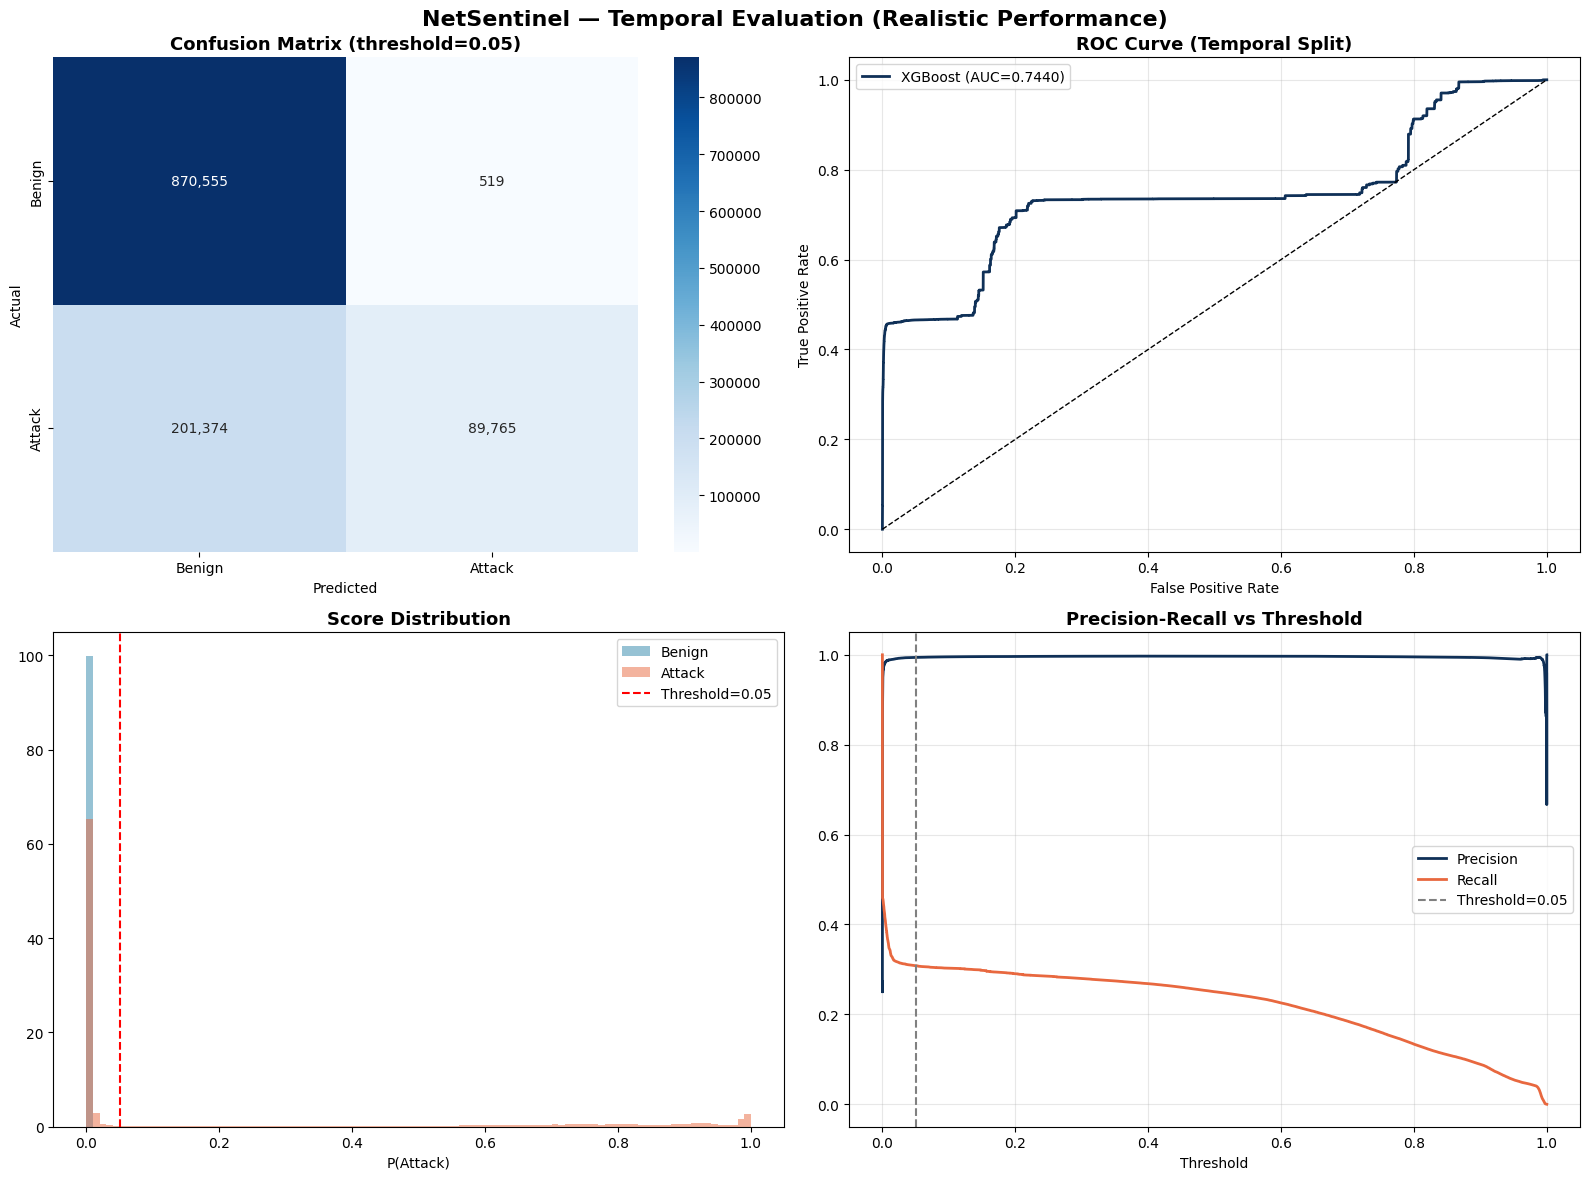

In [8]:
# ═══════════════════════════════════════════════════
# CELL 8 — Visualize Results
# ═══════════════════════════════════════════════════
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'],
            ax=axes[0, 0])
axes[0, 0].set_title(f'Confusion Matrix (threshold={best_threshold})',
                      fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)
axes[0, 1].plot(fpr, tpr, color='#0F3057', lw=2,
                label=f'XGBoost (AUC={auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_title('ROC Curve (Temporal Split)',
                      fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Score Distribution
benign_scores = y_scores[y_test == 0]
attack_scores = y_scores[y_test == 1]
axes[1, 0].hist(benign_scores, bins=100, alpha=0.5, label='Benign',
                color='#2E86AB', density=True)
axes[1, 0].hist(attack_scores, bins=100, alpha=0.5, label='Attack',
                color='#E8683F', density=True)
axes[1, 0].axvline(best_threshold, color='red', linestyle='--',
                    label=f'Threshold={best_threshold}')
axes[1, 0].set_title('Score Distribution',
                      fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('P(Attack)')
axes[1, 0].legend()

# 4. Precision-Recall vs Threshold
from sklearn.metrics import precision_recall_curve
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_test, y_scores)
axes[1, 1].plot(thresholds_pr, precision_curve[:-1], label='Precision',
                color='#0F3057', lw=2)
axes[1, 1].plot(thresholds_pr, recall_curve[:-1], label='Recall',
                color='#E8683F', lw=2)
axes[1, 1].axvline(best_threshold, color='gray', linestyle='--',
                    label=f'Threshold={best_threshold}')
axes[1, 1].set_title('Precision-Recall vs Threshold',
                      fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('NetSentinel — Temporal Evaluation (Realistic Performance)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("../notebooks/temporal_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ═══════════════════════════════════════════════════
# CELL 9 — Analysis by Attack Type
#
# Let's see which attacks the model catches
# and which it misses
# ═══════════════════════════════════════════════════

df_test_results = df_test[['label']].copy()
df_test_results['predicted'] = y_pred_final
df_test_results['score'] = y_scores

print("=" * 60)
print("DETECTION RATE BY ATTACK TYPE")
print("=" * 60)

print(f"\n  {'Attack Type':<35} {'Total':>8} {'Detected':>10} {'Rate':>8}")
print(f"  {'─' * 61}")

for label in df_test_results['label'].unique():
    mask = df_test_results['label'] == label
    total = mask.sum()
    detected = df_test_results.loc[mask, 'predicted'].sum()
    rate = detected / total * 100 if total > 0 else 0
    
    indicator = "✅" if rate > 80 else "🟡" if rate > 50 else "🔴"
    print(f"  {indicator} {label:<33} {total:>8,} {detected:>10,} {rate:>7.1f}%")

DETECTION RATE BY ATTACK TYPE

  Attack Type                            Total   Detected     Rate
  ─────────────────────────────────────────────────────────────
  🔴 BENIGN                             871,074        519     0.1%
  🔴 Infiltration                            36          0     0.0%
  🔴 Bot                                  1,966          0     0.0%
  🔴 PortScan                           158,930        888     0.6%
  🟡 DDoS                               128,027     86,800    67.8%
  ✅ Web Attack � Brute Force             1,507      1,433    95.1%
  ✅ Web Attack � XSS                       652        626    96.0%
  ✅ Web Attack � Sql Injection              21         18    85.7%
